<a href="https://colab.research.google.com/github/piaseckazaneta/30DayMapChallenge2026/blob/main/Day1_2026_Points.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q geopandas matplotlib shapely h3 contextily osmnx

In [ ]:
import osmnx as ox

# 1. Pobieramy oficjalną granicę administracyjną Warszawy jako poligon
# Używamy geocodingu OSMnx
warszawa_admin = ox.geocode_to_gdf("Warszawa, Poland")

# 2. Bardzo ważne: reprojekcja do naszego układu metrycznego!
warszawa_admin = warszawa_admin.to_crs("EPSG:2180")

In [ ]:
import matplotlib.pyplot as plt

def setup_linkedin_canvas(
    aspect_ratio: str = "square"
):
    """
    Initializes a production-grade dark mode canvas optimized for LinkedIn.
    Aspect ratios: 'square' (1:1) or 'portrait' (4:5).
    """
    # 1. Canvas dimensions setup
    if aspect_ratio == "square":
        figsize = (10, 10)
    elif aspect_ratio == "portrait":
        figsize = (8, 10)
    else:
        figsize = (10, 10)

    canvas_bg = "#0F1115"

    fig, ax = plt.subplots(figsize=figsize, facecolor=canvas_bg)
    ax.set_facecolor(canvas_bg)

    # 2. Turn off bounding box axes and ticks
    ax.set_axis_off()

    return fig, ax


def finalize_and_save_linkedin_map(
    fig,
    ax,
    main_title: str,
    subtitle: str,
    author_name: str = "Żaneta Piasecka",
    day_num: int = None,
    output_filename: str = None
):
    """
    Profesjonalny layout: Czysty tytuł biznesowy, nazwisko autora na górze,
    a metadane wyzwania przeniesione dyskretnie do stopki.
    """
    primary_text_color = "#FFFFFF"
    accent_text_color = "#00FFA3"   # Neonowy akcent do autora / kluczowych liczb
    sub_text_color = "#8A94A6"      # Muted slate gray do opisów i stopki

    # 1. Główny, czytelny tytuł biznesowy (duży, wyrazisty)
    fig.text(
        x=0.08,
        y=0.94,
        s=main_title,
        color=primary_text_color,
        fontsize=16,
        fontweight="bold",
        fontfamily="sans-serif",
        ha="left"
    )

    # 2. Podtytuł biznesowy z Twoim nazwiskiem
    sub_author_line = f"{subtitle}  •  {author_name}"
    fig.text(
        x=0.08,
        y=0.91,
        s=sub_author_line,
        color=sub_text_color,
        fontsize=10,
        fontweight="normal",
        fontfamily="sans-serif",
        ha="left"
    )

    # 3. Stopka: Metadane techniczne + Dyskretne oznaczenie wyzwania
    footer_tech = "Warsaw Retail Expansion | CRS: EPSG:2180 | Data: OpenStreetMap"
    footer_challenge = f"#30DayMapChallenge 2026 (Day {day_num:02d})" if day_num else "#30DayMapChallenge 2026"

    fig.text(
        x=0.08,
        y=0.04,
        s=footer_tech,
        color=sub_text_color,
        fontsize=8,
        fontfamily="sans-serif",
        ha="left"
    )

    fig.text(
        x=0.92,
        y=0.04,
        s=footer_challenge,
        color=sub_text_color,
        fontsize=8,
        fontfamily="sans-serif",
        ha="right"
    )

    # 4. Zapis
    if output_filename:
        plt.savefig(
            output_filename,
            dpi=300,
            facecolor=fig.get_facecolor(),
            edgecolor="none",
            bbox_inches="tight"
        )
        print(f"[Export] Saved clean executive map to: {output_filename}")

    return fig

In [ ]:
import geopandas as gpd

# 1. Wczytanie plików
DATA_DIR = "/content/drive/MyDrive/30daymapchallenge2026_Warsaw_pipeline/"

pipeline_gdf = gpd.read_parquet(DATA_DIR + "warszawa_retail_pipeline_final.parquet")
top5_gdf = gpd.read_file(DATA_DIR + "top5_recommended_sites.geojson")
pois_gdf = gpd.read_parquet(DATA_DIR + "warszawa_pois.parquet")

print(f"Załadowano siatkę: {len(pipeline_gdf)} heksagonów.")

Załadowano siatkę: 5331 heksagonów.


In [ ]:
# 2. Weryfikacja układów współrzędnych (EPSG:2180 pod precyzyjną kartografię w metrach)
TARGET_CRS = "EPSG:2180"

for name, gdf in [("Pipeline", pipeline_gdf), ("POIs", pois_gdf), ("Top5", top5_gdf)]:
    print(f"[{name}] Liczba wierszy: {len(gdf)} | Geometria: {gdf.geom_type.unique()} | CRS: {gdf.crs}")

[Pipeline] Liczba wierszy: 5331 | Geometria: ['Polygon'] | CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon"

In [ ]:
# Upewniamy się, że wszystko jest w EPSG:2180
if pois_gdf.crs != TARGET_CRS:
    pois_gdf = pois_gdf.to_crs(TARGET_CRS)
if pipeline_gdf.crs != TARGET_CRS:
    pipeline_gdf = pipeline_gdf.to_crs(TARGET_CRS)

In [ ]:
# 2. Sprawdzenie kolumn w obu ramkach danych
print("Kolumny w pois_gdf:")
print(pois_gdf.columns.tolist())

print("\nPierwsze 3 wiersze pois_gdf:")
display(pois_gdf.head(3))

print("\nKolumny w pipeline_gdf:")
print(pipeline_gdf.columns.tolist())

Kolumny w pois_gdf:
['highway', 'public_transport', 'amenity', 'geometry']

Pierwsze 3 wiersze pois_gdf:


,highway,public_transport,amenity,geometry
0,None,None,restaurant,POINT (633017 480764.404)
1,bus_stop,platform,None,POINT (628664.686 482607.44)
2,None,None,fast_food,POINT (629562.576 487580.285)



Kolumny w pipeline_gdf:
['hex_id', 'geometry', 'transit_stops', 'food_places', 'supermarkets', 'distance_to_center_km', 'has_own_store', 'dist_to_own_store_m', 'cannibalization_risk', 'rev_P10', 'rev_P50', 'rev_P90', 'recommended_format']


[Export] Saved clean executive map to: day_01_points_warsaw.png


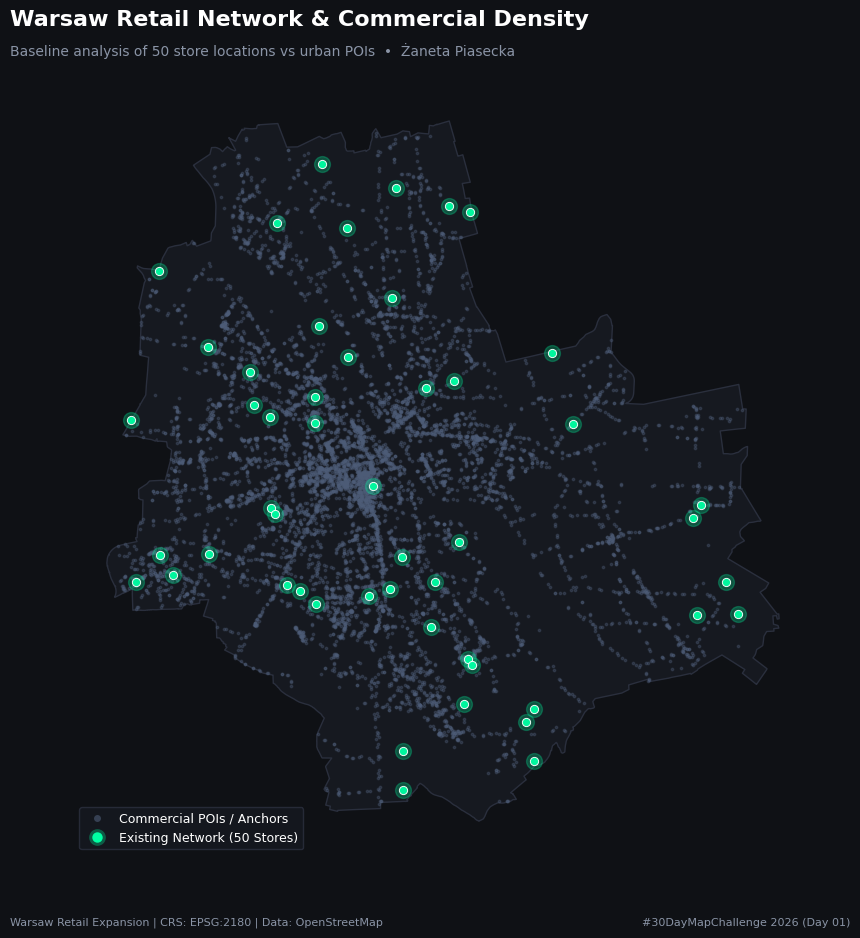

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd

# 1. Punkty sklepów własnych
own_stores_hex = pipeline_gdf[pipeline_gdf["has_own_store"] == True]
own_stores_pts = own_stores_hex.copy()
own_stores_pts["geometry"] = own_stores_hex.geometry.centroid

# 2. Inicjalizacja canvasu
fig, ax = setup_linkedin_canvas(aspect_ratio="square")

# Warstwa 0: Gładka granica Warszawy (z ox.geocode_to_gdf)
warszawa_admin.plot(
    ax=ax,
    facecolor="#161920",
    edgecolor="#2A2F3D",
    linewidth=1.0
)

# Warstwa 1: POIs (tło)
pois_gdf.plot(
    ax=ax,
    color="#4E5D78",
    markersize=3,
    alpha=0.35
)

# Warstwa 2a: Efekt poświaty (glow)
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    markersize=130,
    alpha=0.25
)

# Warstwa 2b: Właściwe punkty z białą obwódką
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    edgecolor="#FFFFFF",
    linewidth=0.7,
    markersize=35,
    alpha=0.95
)

# Legenda

from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

# Kolor bazowy miętowo-zielony
mint_hex = "#00FFA3"

# Tworzymy kolor krawędzi z 25% krycia (dokładnie tyle, ile miała dolna warstwa na mapie)
mint_glow_rgba = to_rgba(mint_hex, alpha=0.30)

custom_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Commercial POIs / Anchors',
        markerfacecolor='#4E5D78',
        markeredgecolor='none',
        markersize=5,
        alpha=0.6
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=f'Existing Network ({len(own_stores_pts)} Stores)',
        markerfacecolor=mint_hex,         # Wypełnienie: nasycona zieleń
        markeredgecolor=mint_glow_rgba,   # Krawędź: ta sama zieleń, ale półprzezroczysta poświata
        markeredgewidth=4.5,              # Szerokość przezroczystej otoczki
        markersize=7.5                    # Rozmiar rdzenia
    )
]

legend = ax.legend(
    handles=custom_handles,
    loc="lower left",
    frameon=True,
    facecolor="#161920",
    edgecolor="#2A2F3D",
    fontsize=9,
    labelcolor="#FFFFFF"
)
legend.get_frame().set_alpha(0.85)

# 5. Finalizacja i eksport
finalize_and_save_linkedin_map(
    fig=fig,
    ax=ax,
    main_title="Warsaw Retail Network & Commercial Density",
    subtitle="Baseline analysis of 50 store locations vs urban POIs",
    author_name="Żaneta Piasecka",
    day_num=1,
    output_filename="day_01_points_warsaw.png"
)

plt.show()